# 비지도학습

## 군집

In [1]:
import numpy as np
# wget https://bit.ly/fruits_300_data -O fruits_300.npy
fruits = np.load('./data/fruits_300.npy')

In [34]:
# 300장의 과일 이미지를 담고 있음
# 100 x 100 픽셀 값은 0~255 사이의 값을 가지고 있음 (흑백)
# 레이블이 없다고 간주함. 
fruits.shape

(300, 100, 100)

In [35]:
fruits[0, 0, :]

array([  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   2,   1,   2,   2,   2,   2,   2,   2,   1,   1,
         1,   1,   1,   1,   1,   1,   2,   3,   2,   1,   2,   1,   1,
         1,   1,   2,   1,   3,   2,   1,   3,   1,   4,   1,   2,   5,
         5,   5,  19, 148, 192, 117,  28,   1,   1,   2,   1,   4,   1,
         1,   3,   1,   1,   1,   1,   1,   2,   2,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1], dtype=uint8)

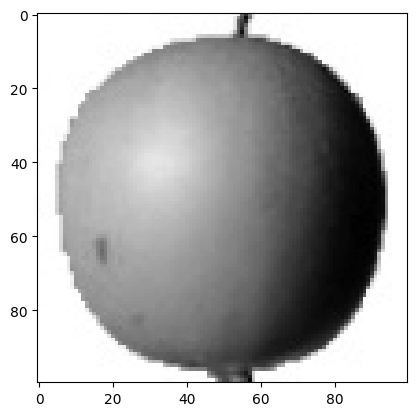

In [36]:
# 픽셀을 시각적으로 확인하기
import matplotlib.pyplot as plt
plt.imshow(fruits[0], cmap='gray_r')
# plt.imshow(fruits[0], cmap='gray')
plt.show()

In [37]:
apple = fruits[0:100].reshape(-1, 100*100)
pineapple = fruits[100:200].reshape(-1, 100*100)
banana = fruits[200:300].reshape(-1, 100*100)

In [38]:
# apple.shape
# apple[0]
apple.mean(axis=1)
# 사과 100장 각각의 평균 픽셀 값(밝기)

array([ 88.3346,  97.9249,  87.3709,  98.3703,  92.8705,  82.6439,
        94.4244,  95.5999,  90.681 ,  81.6226,  87.0578,  95.0745,
        93.8416,  87.017 ,  97.5078,  87.2019,  88.9827, 100.9158,
        92.7823, 100.9184, 104.9854,  88.674 ,  99.5643,  97.2495,
        94.1179,  92.1935,  95.1671,  93.3322, 102.8967,  94.6695,
        90.5285,  89.0744,  97.7641,  97.2938, 100.7564,  90.5236,
       100.2542,  85.8452,  96.4615,  97.1492,  90.711 , 102.3193,
        87.1629,  89.8751,  86.7327,  86.3991,  95.2865,  89.1709,
        96.8163,  91.6604,  96.1065,  99.6829,  94.9718,  87.4812,
        89.2596,  89.5268,  93.799 ,  97.3983,  87.151 ,  97.825 ,
       103.22  ,  94.4239,  83.6657,  83.5159, 102.8453,  87.0379,
        91.2742, 100.4848,  93.8388,  90.8568,  97.4616,  97.5022,
        82.446 ,  87.1789,  96.9206,  90.3135,  90.565 ,  97.6538,
        98.0919,  93.6252,  87.3867,  84.7073,  89.1135,  86.7646,
        88.7301,  86.643 ,  96.7323,  97.2604,  81.9424,  87.1

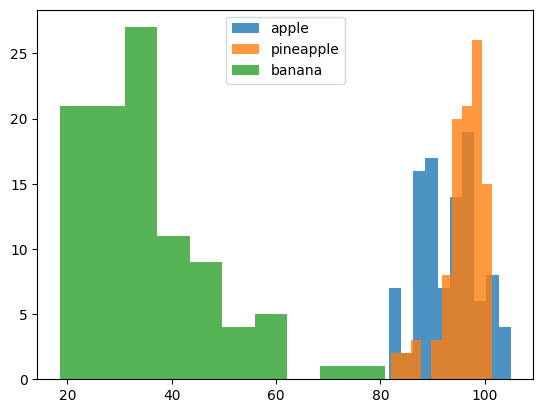

In [39]:
# 각각 과일별 사진들의 밝기 분포
# - 바나나가 눈에 띄게 밝기 평균이 낮다. (빈 공간 많아서)
plt.hist(apple.mean(axis=1), alpha=0.8, label='apple')
plt.hist(pineapple.mean(axis=1), alpha=0.8, label='pineapple')
plt.hist(banana.mean(axis=1), alpha=0.8, label='banana')
plt.legend()
plt.show()

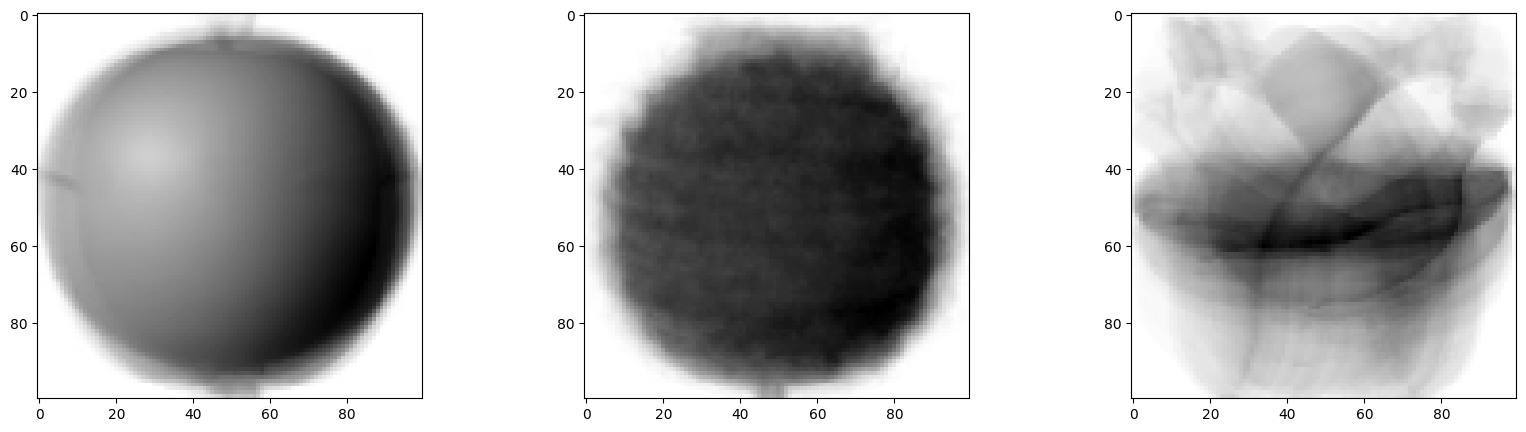

In [40]:
apple_mean     = apple.mean(axis=0).reshape(100, 100)
pineapple_mean = pineapple.mean(axis=0).reshape(100, 100)
banana_mean    = banana.mean(axis=0).reshape(100, 100)

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(apple_mean,     cmap='gray_r')
axs[1].imshow(pineapple_mean, cmap='gray_r')
axs[2].imshow(banana_mean,    cmap='gray_r')
plt.show()

In [41]:
abs_diff = np.abs(fruits - apple_mean)
abs_mean = np.mean(abs_diff, axis=(1, 2))

In [42]:
abs_diff
abs_mean.shape # 모든 이미지에서 사과와 절대 차이 계산한 값

(300,)

In [43]:
apple_index = np.argsort(abs_mean)[:100] # 정렬 다시 해줌

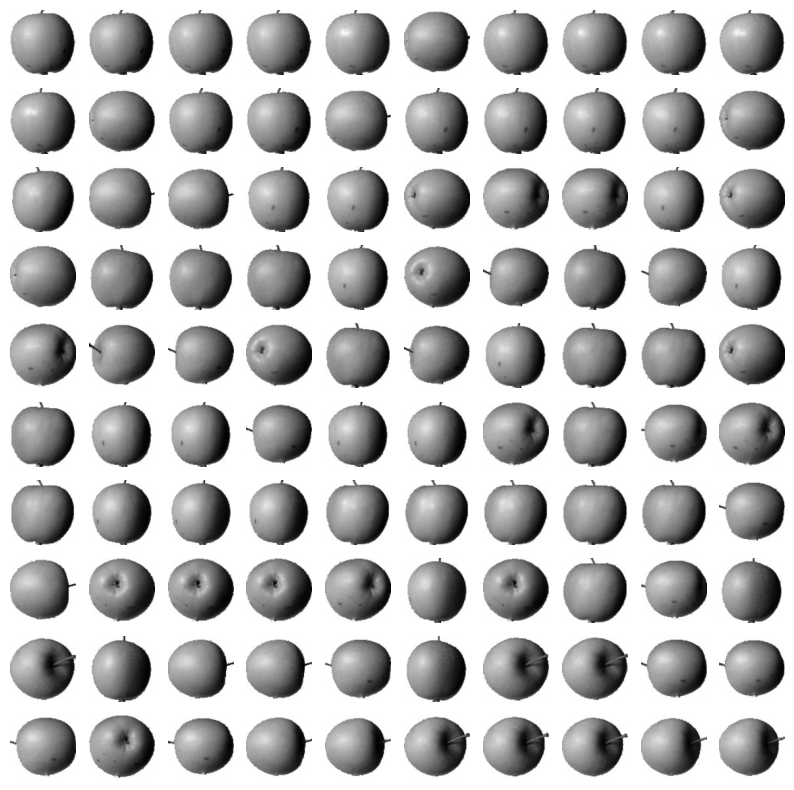

In [44]:
apple_index = apple_index.reshape(10, 10)
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for i in range(10):
    for j in range(10):
        axs[i, j].imshow(fruits[apple_index[i, j]], cmap='gray_r')
        axs[i, j].axis('off')
plt.show()

In [45]:
# abs_diff = np.abs(fruits - banana_mean)
# abs_mean = np.mean(abs_diff, axis=(1, 2))

# banana_index = np.argsort(abs_mean)[:100] # 정렬 다시 해줌

# banana_index = banana_index.reshape(10, 10)
# fig, axs = plt.subplots(10, 10, figsize=(10, 10))
# for i in range(10):
#     for j in range(10):
#         axs[i, j].imshow(fruits[banana_index[i, j]], cmap='gray_r')
#         axs[i, j].axis('off')
# plt.show()

# print(abs_mean[banana_index[-5:]])

# K-Means

In [46]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

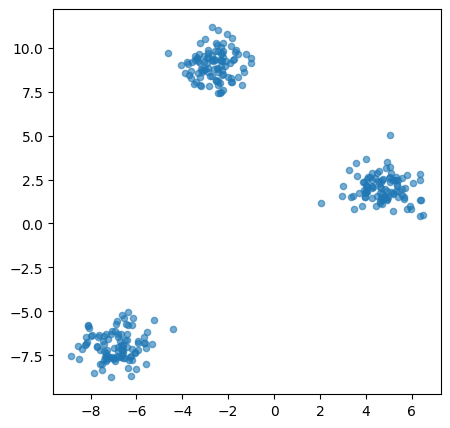

In [47]:
X, y_true = make_blobs(300, centers=3, cluster_std=0.8, random_state=42)
plt.figure(figsize=(5,5))
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.6)
plt.show()

In [48]:
# 실제 학습과정
km = KMeans(3, random_state=42)
km.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [49]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

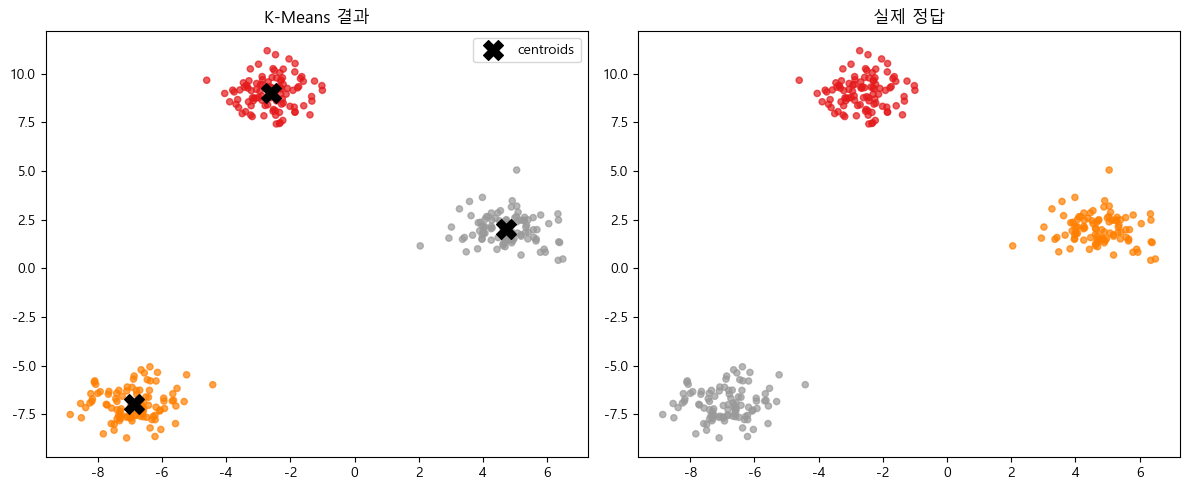

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 왼쪽: K-Means 결과 (클러스터 번호로 색)
axes[0].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='Set1', s=20, alpha=0.7)
axes[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                marker='X', s=200, c='black', label='centroids')
axes[0].set_title('K-Means 결과')
axes[0].legend()

# 오른쪽: 실제 정답 (y_true로 색)
axes[1].scatter(X[:, 0], X[:, 1], c=y_true, cmap='Set1', s=20, alpha=0.7)
axes[1].set_title('실제 정답')

plt.tight_layout()
plt.show()

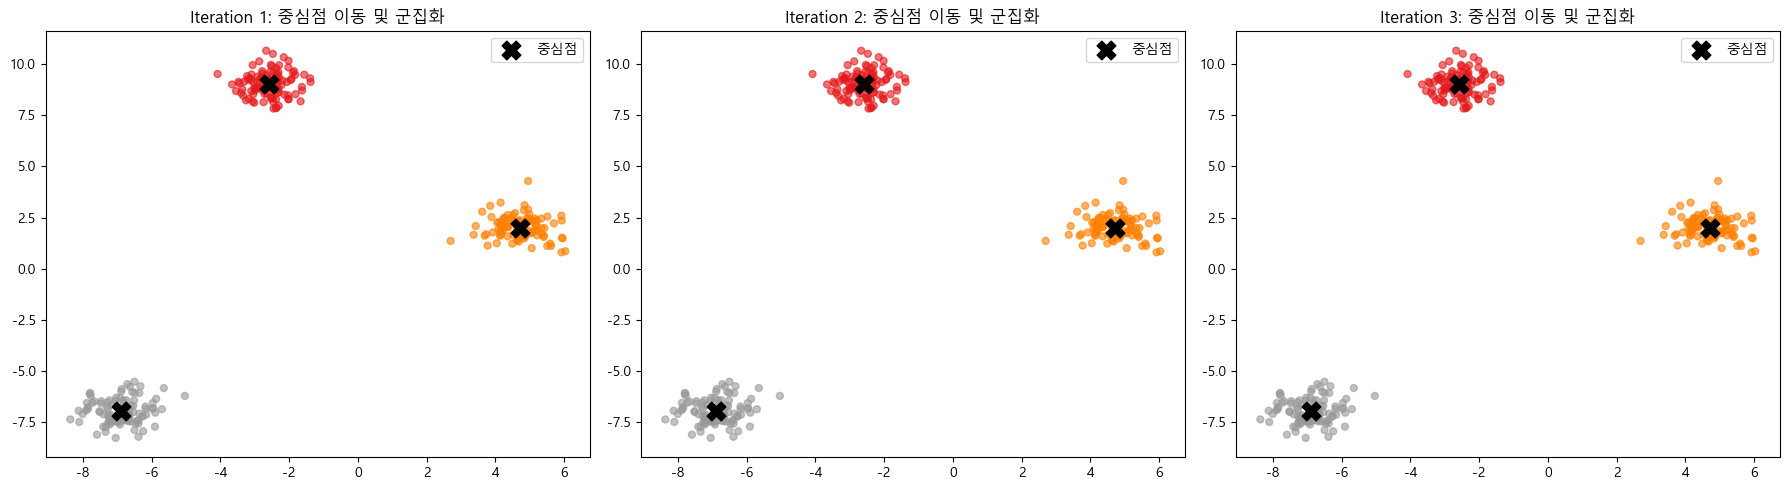

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 예제 데이터 생성
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.6,
    random_state=42
)

# 중심점 이동 과정을 저장할 리스트
centers_history = []
labels_history = []

# K-Means를 iteration별로 직접 실행하듯이 확인
for i in range(1, 4):
    km = KMeans(
        n_clusters=3,
        init='random',
        n_init=1,
        max_iter=i,
        random_state=42
    )
    km.fit(X)

    centers_history.append(km.cluster_centers_)
    labels_history.append(km.labels_)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, ax in enumerate(axes):
    labels = labels_history[i]
    centers = centers_history[i]

    ax.scatter(
        X[:, 0], X[:, 1],
        c=labels,
        cmap='Set1',
        s=25,
        alpha=0.6
    )

    ax.scatter(
        centers[:, 0], centers[:, 1],
        c='black',
        marker='X',
        s=180,
        label='중심점'
    )

    ax.set_title(f'Iteration {i+1}: 중심점 이동 및 군집화')
    ax.legend()

plt.tight_layout()
plt.show()

### K-Means 과정

In [52]:
fruits_2d = fruits.reshape(-1, 100*100)  # (300, 10000)

km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_2d)   # y 없이 fit!
# KMeans는 비지도학습이기 때문에 y 없이 x만 넣는다.

print(np.unique(km.labels_, return_counts=True))
# ([0, 1, 2], [112, 98, 90])

print(km.n_iter_)   # 4 — 4번만에 수렴

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))
4


In [53]:
km.labels_

array([2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], d

In [54]:
print(np.unique(km.labels_, return_counts=True))
# ([0, 1, 2], [112, 98, 90])

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


In [55]:
print(km.n_iter_)   # 4 — 4번만에 수렴

4


In [56]:
km.cluster_centers_ # 알고리즘이 찾아낸 군집 centroid의 좌표

array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.10204082, 1.07142857, 1.10204082, ..., 1.        , 1.        ,
        1.        ],
       [1.01111111, 1.01111111, 1.01111111, ..., 1.        , 1.        ,
        1.        ]], shape=(3, 10000))

In [57]:
km.inertia_  # 각 데이터로부터 centroid까지 거리의 제곱합. SSE
# 작을수록 군집이 뭉쳐있다.

5075273831.931917

In [58]:
def draw_fruits(arr, ratio=1):
    n = len(arr)
    rows = int(np.ceil(n / 10))
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows, cols,
                             figsize=(cols*ratio, rows*ratio),
                             squeeze=False)
    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off')
    plt.show()

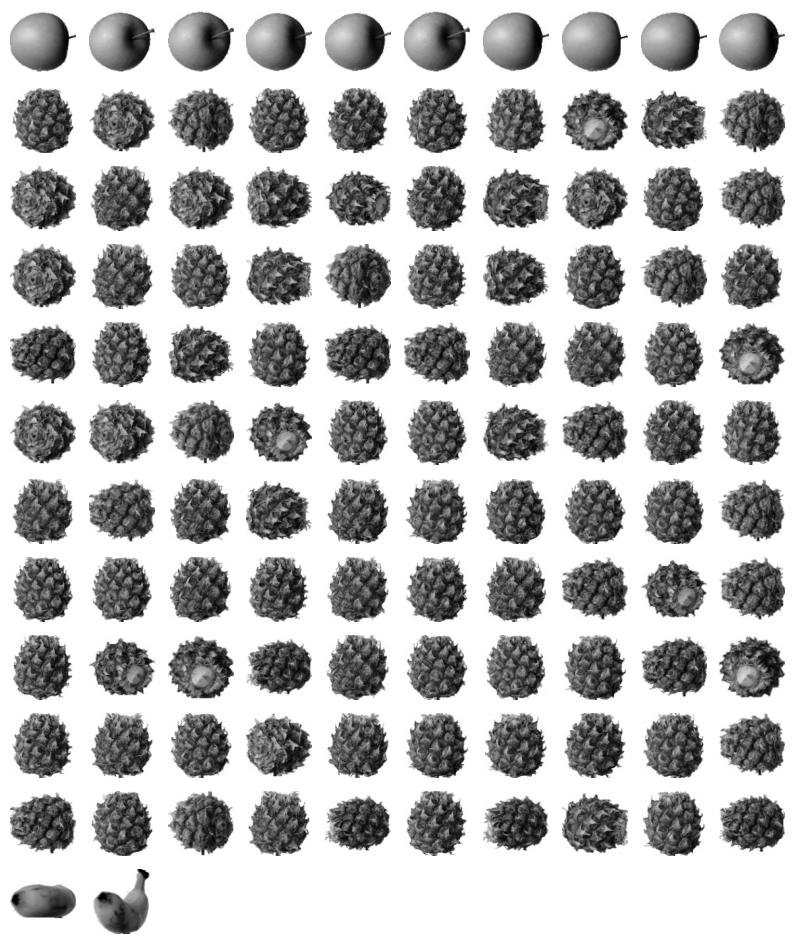

In [59]:
draw_fruits(fruits[km.labels_ == 0])   # 파인애플 군집 / 사과 10개 바나나 2개 (섞임)

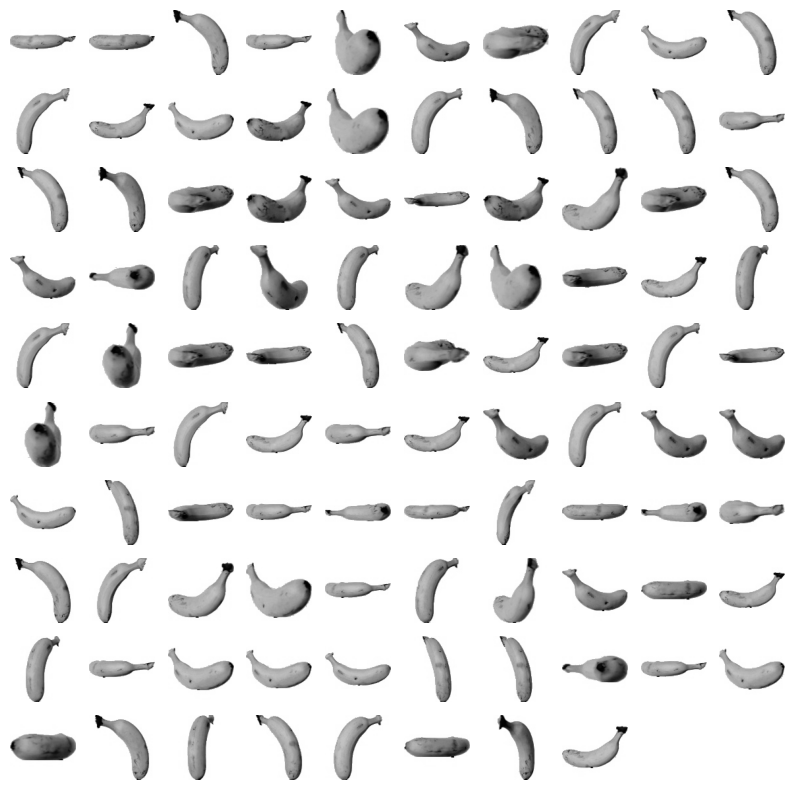

In [60]:
draw_fruits(fruits[km.labels_ == 1])  # 바나나 군집

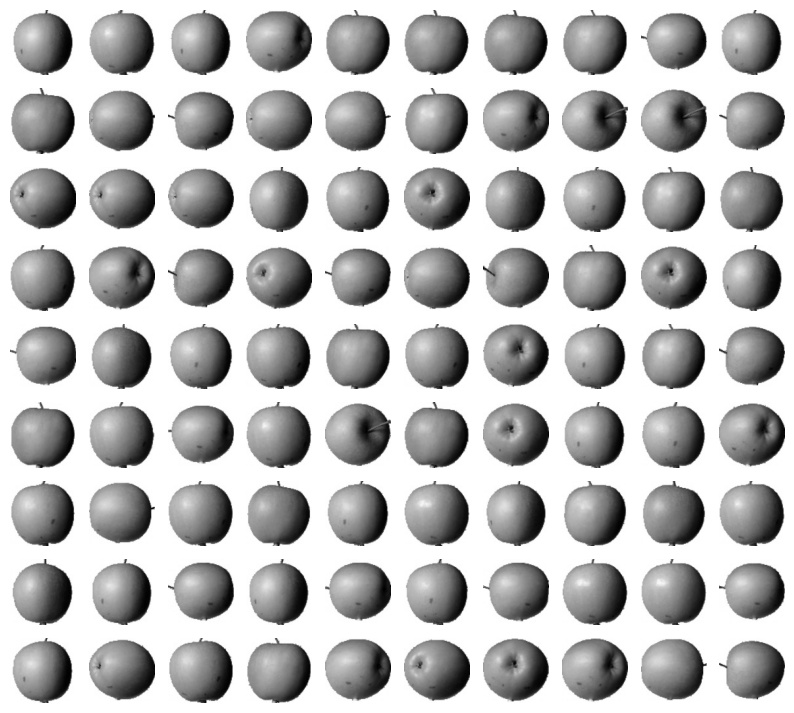

In [61]:
draw_fruits(fruits[km.labels_ == 2])  # 사과 군집

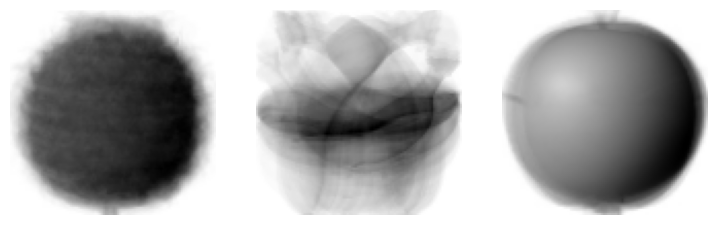

In [62]:
# 각 군집별 평균 군집 이미지
draw_fruits(km.cluster_centers_.reshape(-1, 100, 100), ratio=3)

In [63]:
# 100번째 이미지 = 파인애플
km.transform(fruits_2d[100:101])
# 각 군집의 centroid까지의 거리 => 가장 가까운 클러스터로 할당

array([[3400.24197319, 8837.37750892, 5279.33763699]])

In [64]:
km.predict(fruits_2d[100:101]) # => 0번 군집으로 예측

array([0], dtype=int32)

# 최적의 K값 찾기

## 엘보우 방법

In [65]:
inertia = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(fruits_2d)
    inertia.append(km.inertia_)

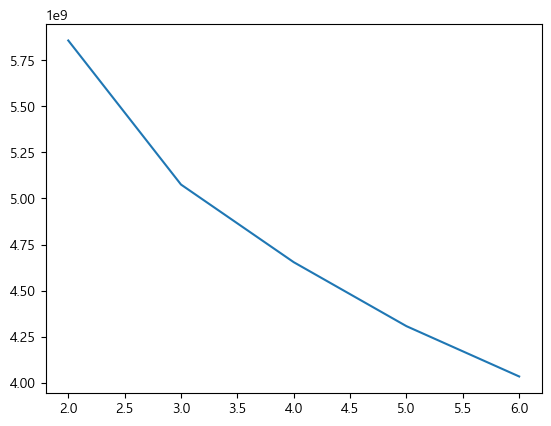

In [66]:
plt.plot(range(2, 7), inertia)
plt.show()

---

# 이상탐지

In [67]:
# 정상 데이터 + 이상치 몇 개 섞기
X_normal, _ = make_blobs(n_samples=300, centers=3,
                          cluster_std=0.8, random_state=42)
X_anomaly  = np.array([[8, 8], [-6, 7], [5, -5]])   # 군집 밖 이상치
X_all = np.vstack([X_normal, X_anomaly])

In [68]:
km = KMeans(n_clusters=3, random_state=42)
km.fit(X_normal)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [69]:
dist = km.transform(X_all) # 모든 샘플(이상치 포함)과 가까운 centroid의 거리

In [70]:
min_dist = dist.min(axis=1)
min_dist.shape
# dist.shape

(303,)

In [71]:
dist.shape

(303, 3)

In [72]:
threshold = np.percentile(min_dist, 95)  # 정규분포 95%
is_anomaly = min_dist > threshold  # 이상이면 이상치

In [73]:
threshold

np.float64(1.8327073381304277)

In [74]:
is_anomaly.sum() # 이상치 후보 16개

np.int64(16)

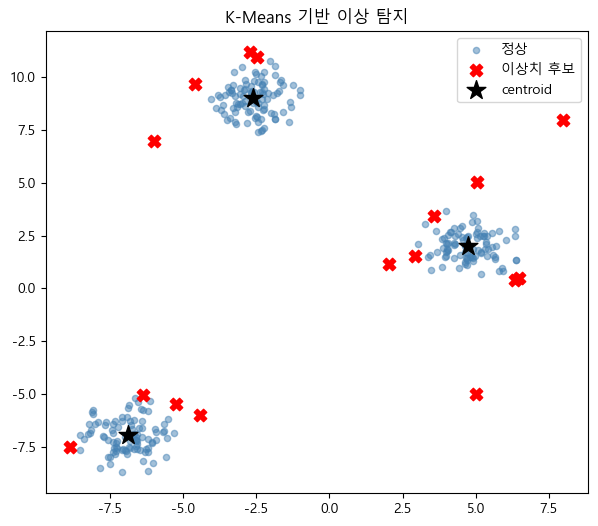

In [75]:
# 시각화
plt.figure(figsize=(7, 6))
plt.scatter(X_all[~is_anomaly, 0], X_all[~is_anomaly, 1],
            c='steelblue', s=20, alpha=0.5, label='정상')
plt.scatter(X_all[is_anomaly,  0], X_all[is_anomaly,  1],
            c='red',       s=80, marker='X', label='이상치 후보')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c='black', marker='*', s=200, label='centroid')
plt.legend()
plt.title('K-Means 기반 이상 탐지')
plt.show()

In [76]:
for p in [90, 95, 97, 99, 99.5]:
    t = np.percentile(min_dist, p)
    n = (min_dist > t).sum()
    print(f"percentile={p}% | threshold={t:.2f} | 이상치={n}개")

percentile=90% | threshold=1.70 | 이상치=31개
percentile=95% | threshold=1.83 | 이상치=16개
percentile=97% | threshold=2.15 | 이상치=10개
percentile=99% | threshold=3.06 | 이상치=4개
percentile=99.5% | threshold=5.37 | 이상치=2개


# PCA 주성분분석

---

In [77]:
from sklearn.decomposition import PCA

# fruits_2d : (300, 10000)
fruits_2d.shape

(300, 10000)

In [78]:
pca = PCA(50)        # 10,000 => 50의 주성분(PC)으로 압축해줘
pca.fit(fruits_2d)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [79]:
pca.components_.shape

(50, 10000)

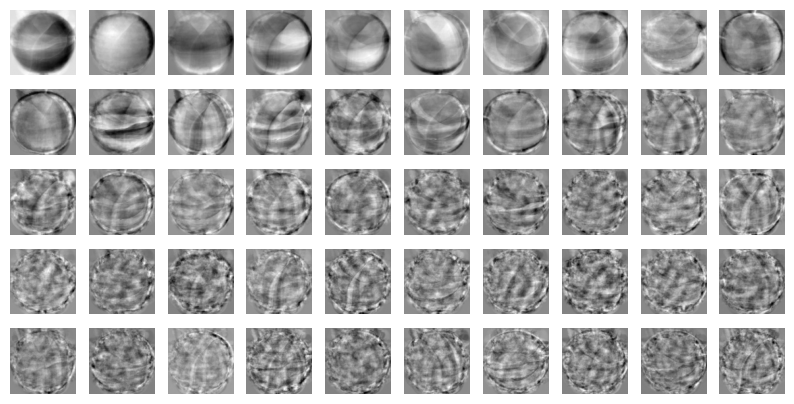

In [80]:
# 주성분 이미지 시각화
draw_fruits(pca.components_.reshape(-1, 100, 100))

In [81]:
fruits_pca = pca.transform(fruits_2d)

In [82]:
fruits_pca.shape # 10000개의 특성이 50개 주성분으로 압축

(300, 50)

- 압축된 주성분 복원 (실습시간에 AI에게 참고)

In [83]:
# 설명된 분산
pca.explained_variance_
pca.explained_variance_ratio_ # 첫번째 주성분이 42% 가량을 설명, 두번째 주성분이 10% 가량을 설명

array([0.42357017, 0.09941755, 0.06577863, 0.04031172, 0.03416875,
       0.03281329, 0.02573267, 0.02054963, 0.01372276, 0.01342773,
       0.01152146, 0.00944596, 0.00878232, 0.00846697, 0.00693049,
       0.00645188, 0.00578895, 0.00511201, 0.00486383, 0.00480347,
       0.00447836, 0.0043731 , 0.0040803 , 0.00389476, 0.00372435,
       0.00359273, 0.00331449, 0.0031778 , 0.00304325, 0.00303764,
       0.00288875, 0.0027584 , 0.00264923, 0.00255739, 0.00252155,
       0.00247339, 0.00239451, 0.00230889, 0.00221909, 0.00216903,
       0.00213865, 0.00196116, 0.00193027, 0.00189563, 0.00184803,
       0.00182047, 0.00172675, 0.0016731 , 0.00163241, 0.00158824])

In [84]:
pca = PCA(n_components=0.5) # 분산의 50% 이상을 설명하는 주성분 숫자를 찾아줘.
pca.fit(fruits_2d)

pca.n_components_ # 몇 개인지 확인

np.int64(2)

In [85]:
fruits_pca = pca.transform(fruits_2d)
fruits_pca.shape

(300, 2)

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

target = np.array([0]*100 + [1]*100 + [2]*100)

# 원본 10,000 특성 사용
scores = cross_validate(LogisticRegression(), fruits_2d, target)
print(f"score: {np.mean(scores['test_score']):.4f}")   # 0.9967
print(f"time:  {np.mean(scores['fit_time']):.4f}s")    # ~1.46s

# PCA 50 특성 사용
pca = PCA(n_components=50)
fruits_pca = pca.fit_transform(fruits_2d)

scores = cross_validate(LogisticRegression(), fruits_pca, target)
print(f"score: {np.mean(scores['test_score']):.4f}")   # 0.9967
print(f"time:  {np.mean(scores['fit_time']):.4f}s")    # ~0.027s

score: 0.9967
time:  0.3088s
score: 0.9967
time:  0.0088s
